## Waste management

This notebook treats the output dataset from Cottom, J.W., Cook, E. & Velis, C.A. A local-to-global emissions inventory of macroplastic pollution. Nature 633, 101–108 (2024). https://doi.org/10.1038/s41586-024-07758-6 folder SD_05_Cottom_et_al_V1.1.0-G-1223_SPOT_MFA_Outputs_Municipal.xlsx \
The original data (50000 municipalities) was filtred and only 12266 municipalities are considered.

In [1]:
import numpy as np
from geopy.geocoders import Nominatim
import pandas as pd
#from tqdm import tqdm
#import time
#from geopy.exc import GeocoderRateLimited

## Geolocate cities

In [ ]:
geolocator = Nominatim(user_agent="neladobiasova02@gmail.com")

In [89]:
folder = pd.read_csv("inputs\municipalities list.csv", sep = ';')
folder.head() 

,Municipality
0,Placer
1,San Martín
2,Nanping
3,Valencia
4,Jingyuan


## Associate geographical coordinates to municipalities.

In [ ]:
cache = {}
rows = []
for name in tqdm(folder['Municipality']):
    if name in cache:
        lat, lon = cache[name]
    else:
        try:
            location = geolocator.geocode(name, timeout=10)
            if location:
                rows.append([name, location.latitude, location.longitude])
            else:
                rows.append([name, None, None])

            time.sleep(1)  # REQUIRED

        except GeocoderRateLimited:
            print("Rate limited, sleeping...")
            time.sleep(2)  # backoff



100%|██████████| 1724/1724 [32:32<00:00,  1.13s/it]


In [ ]:
rows
out = pd.DataFrame(rows, columns=['Municipality', 'Latitude', 'Longitude'])
out.to_csv("municipalities geocoded.csv", index=False)

In [ ]:
out.tail()

,Municipality,Latitude,Longitude
1719,King,33.588178,-100.217897
1720,Kanchanpur,23.917402,92.233912
1721,Santiago,9.869479,-83.798075
1722,Parsa,25.890230,84.973473
1723,Bor,56.359829,44.054264


## Visualise data

In [2]:
folder = pd.read_csv("inputs\\Cottom filtered table.csv", sep=";", header=1) # folder with 12266 municipalities
folder.dropna(axis=0,inplace=True)
folder

,Municipality,Latitude,Longitude,Population_2020,wg,wg_per_cap,pwg,pwg_per_cap,open_burn_MSW,plas_debris_em,...,plas_em_per_cap,rigid_plas_deb_em,flex_plas_deb_em,rigid_plas_ob_em,flex_plas_ob_em,plas_litter_em,plas_uncol_em,plas_collection_em,plas_disp_em,plas_recy_em
0,Suzhou,31.311123,120.621288,30753142,12574953,1.12,1723631,0.15,19481,6259,...,0.29,3342,2918,1190,1487,1980,4425,2495,20,16
1,Istanbul,41.006381,28.975872,23100092,9565469,1.13,1285262,0.15,69384,10695,...,0.87,5348,5347,4168,5186,2080,15317,2491,85,75
2,Gyeonggi-do,37.288468,127.053523,20394141,6390487,0.86,748341,0.10,1221845,73119,...,10.63,31148,41971,60046,83701,2830,113509,2124,97180,1223
3,Bangalore,12.976794,77.590082,19057961,4393027,0.63,470877,0.07,947461,68084,...,8.96,29103,38982,43111,59636,2229,106565,1451,58782,1803
4,Lahore,31.565682,74.314183,14520442,3350833,0.63,354262,0.07,526 031,8 642,...,4.46,3674,4968,23469,32618,1260,8961,1154,53199,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12259,King,33.588178,-100.217897,525,395,2.06,41,0.21,0,0,...,0.28,0,0,0,0,0,0,0,0,0
12260,Kanchanpur,23.917402,92.233912,483,86,0.49,8,0.04,35,1,...,8.50,0,0,1,2,0,4,0,0,0
12261,Santiago,9.869479,-83.798075,386,77,0.55,9,0.06,17,2,...,10.33,1,1,1,1,0,3,0,1,0
12262,Parsa,25.890230,84.973473,383,223,1.6,27,0.19,1,0,...,0.87,0,0,0,0,0,0,0,0,0


In [4]:
data_points = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs  
import cartopy.feature as cfeature
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

In [6]:
latitudes_folder  = np.array(folder["Latitude"], dtype=float)
longitudes_folder = np.array(folder["Longitude"], dtype=float)

points_folder = list(zip(latitudes_folder, longitudes_folder))

lats_folder   = [p[0] for p in points_folder]
lons_folder   = [p[1] for p in points_folder]
# Format: (latitude, longitude, "Label")

# ──────────────────────────────────────────────────────────────────────────────
latitudes_data  = np.array(data_points["Lat_center"], dtype=float)
longitudes_data = np.array(data_points["Lon_center"], dtype=float)

points_data = list(zip(latitudes_data, longitudes_data))
# Format: (latitude, longitude, "Label")

lats_data   = [p[0] for p in points_data]
lons_data   = [p[1] for p in points_data]

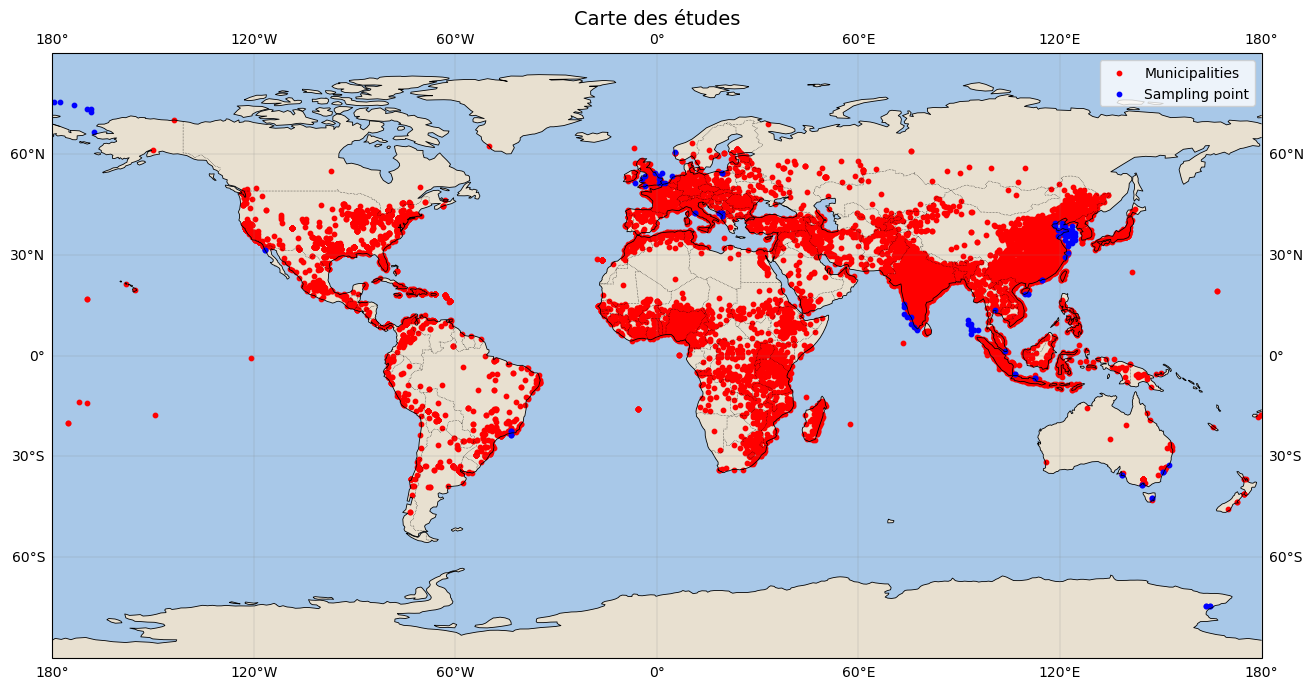

In [7]:
fig = plt.figure(figsize=(14, 7))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_global()
ax.add_feature(cfeature.LAND,       facecolor="#e8e0d0")
ax.add_feature(cfeature.OCEAN,      facecolor="#a8c8e8")
ax.add_feature(cfeature.COASTLINE,  linewidth=0.6)
ax.add_feature(cfeature.BORDERS,    linewidth=0.4, linestyle=":")
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)

ax.scatter(lons_folder, lats_folder, s=10, color="red", zorder=1, transform=ccrs.PlateCarree(), label = 'Municipalities')
ax.scatter(lons_data, lats_data, s=10, color="blue", zorder=1, transform=ccrs.PlateCarree(), label = 'Sampling point')

plt.legend()
plt.title("Carte des études", fontsize=14)
plt.tight_layout()
plt.show()

## Treat data

In [8]:
# Create a dictionary of arrays for all numeric columns
folder_arrays = {}
column_names = []
for col in folder.columns:
    try:
        folder_arrays[col] = np.array(folder[col], dtype=float)
        column_names.append(col)
    except (ValueError, TypeError):
        pass

# Zip all array values from the dictionary
points_folder = list(zip(*folder_arrays.values()))

In [9]:
def compute_distances(lat, lon, lats, lons):
    """Computes distances in km using the Haversine formula"""
    R = 6378
    lat1, lon1, lat2, lon2 = np.radians(lat), np.radians(lon), np.radians(lats), np.radians(lons)
    dLat = (lat2-lat1)
    dLon = (lon2-lon1)
    d = 2*R*np.arcsin(np.sqrt((np.sin(dLat/2))**2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dLon/2))**2))
    return d

points_arr = np.array(points_folder)
coords     = np.array([(p[1], p[2]) for p in points_folder], dtype=float)

In [10]:
column_names

['Latitude',
 'Longitude',
 'Population_2020',
 'wg',
 'pwg',
 'pwg_per_cap',
 'plas_debris_em_per_cap',
 'plas_burn_em_per_cap',
 'plas_em_per_cap',
 'rigid_plas_deb_em',
 'flex_plas_deb_em',
 'rigid_plas_ob_em',
 'flex_plas_ob_em',
 'plas_litter_em',
 'plas_uncol_em',
 'plas_collection_em',
 'plas_disp_em',
 'plas_recy_em']

In [11]:
def city_association(method, lat, lon, coords, points_array):
    """ Returns distance from sapling point to nearest municipality and its associated values. 4 ways to search for nearest point exist:
    nearest point - finds the smallest distance
    sum of 5 nearests - finds 5 smallest distances and does the sum of values for each columns, mean distance is considered
    100 km radius - finds the smallest distance and then sums all municipalities in a 100 km radius around the nearest one
    500 km radius - finds the smallest distance and then sums all municipalities in a 50 km radius around the nearest one
    """

    distances = compute_distances(lat, lon, coords[:, 0], coords[:, 1])
    distances = distances[np.isfinite(distances)]
    
    # Find closest point
    if method == "nearest point":
        idx_nearest = np.argmin(distances)
        nearest = points_array[idx_nearest]
        nearest = np.array(nearest, dtype=object)
        min_distance = distances[idx_nearest]
        return (min_distance, nearest[2:])  # Return distance and parameters of nearest point
    
    if method == "sum of 5 nearests":
        idx_smallest_five = np.argpartition(distances, 5)[:5] # rearranges the indices so that the 5 smallest values are guaranteed to be in the first 5 positions of the result 
        nearby = points_array[idx_smallest_five]
        min_distances = distances[idx_smallest_five]
        nearby = np.nansum(nearby, axis=0)
        return (np.nanmean(min_distances, axis=0), nearby[2:])
    
    if method == "100 km radius":
        mask = distances <= 100
        nearby = points_array[mask]
        nearby = np.nansum(nearby, axis=0)
        min_distance = np.nanmean(distances[mask])
        return (min_distance, nearby[2:])
    
    if method == "500 km radius":
        mask = distances <= 500
        nearby = points_array[mask]
        nearby = np.nansum(nearby, axis=0)
        min_distance = np.nanmean(distances[mask])
        return (min_distance, nearby[2:])


In [12]:
# Find nearest municipaliities with 4 different methods

result_np = []
result_sum5 = []
result_100km = []
result_500km = []
for lat, lon in zip(lats_data, lons_data):
    output = city_association(method = "nearest point",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_np.append(output)
    output = city_association(method = "sum of 5 nearests",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_sum5.append(output)
    output = city_association(method = "100 km radius",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_100km.append(output)
    output = city_association(method = "500 km radius",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_500km.append(output)

df_np = pd.DataFrame(result_np[i] for i in range(len(result_np)))
df_np = pd.concat([df_np.drop(1, axis=1),df_np[1].apply(pd.Series)], axis=1)
df_np.columns = ['Distance nearest_point'] + [f"{column_names[i]} nearest_point" for i in range(2, len(df_np.columns)+1)]


df_sum5 = pd.DataFrame(result_sum5[i] for i in range(len(result_sum5)))
df_sum5 = pd.concat([df_sum5.drop(1, axis=1),df_sum5[1].apply(pd.Series)], axis=1)
df_sum5.columns = ['Distance sum5'] + [f"{column_names[i]} sum5" for i in range(2, len(df_sum5.columns)+1)]

df_100km = pd.DataFrame(result_100km[i] for i in range(len(result_100km)))
df_100km = pd.concat([df_100km.drop(1, axis=1),df_100km[1].apply(pd.Series)], axis=1)
df_100km.columns = ['Distance 100km'] + [f"{column_names[i]} 100km" for i in range(2, len(df_100km.columns)+1)]

df_500km = pd.DataFrame(result_500km[i] for i in range(len(result_500km)))
df_500km = pd.concat([df_500km.drop(1, axis=1),df_500km[1].apply(pd.Series)], axis=1)
df_500km.columns = ['Distance 500km'] + [f"{column_names[i]} 500km" for i in range(2, len(df_500km.columns)+1)]

C:\Users\nelad\AppData\Local\Temp\ipykernel_22864\2127308194.py:31: RuntimeWarning: Mean of empty slice
  min_distance = np.nanmean(distances[mask])
C:\Users\nelad\AppData\Local\Temp\ipykernel_22864\2127308194.py:38: RuntimeWarning: Mean of empty slice
  min_distance = np.nanmean(distances[mask])


In [13]:
output = pd.concat([df_np, df_sum5, df_100km, df_500km], axis=1)
output

,Distance nearest_point,Population_2020 nearest_point,wg nearest_point,pwg nearest_point,pwg_per_cap nearest_point,plas_debris_em_per_cap nearest_point,plas_burn_em_per_cap nearest_point,plas_em_per_cap nearest_point,rigid_plas_deb_em nearest_point,flex_plas_deb_em nearest_point,...,plas_em_per_cap 500km,rigid_plas_deb_em 500km,flex_plas_deb_em 500km,rigid_plas_ob_em 500km,flex_plas_ob_em 500km,plas_litter_em 500km,plas_uncol_em 500km,plas_collection_em 500km,plas_disp_em 500km,plas_recy_em 500km
0,101.652692,36523.0,20912.0,2306.0,0.17,0.18,0.00,0.18,5.0,2.0,...,466.48,49310.0,61867.0,82912.0,106130.0,3945.0,226429.0,2020.0,64722.0,3103.0
1,99.550672,69286.0,57271.0,6042.0,0.24,0.27,0.00,0.27,13.0,6.0,...,467.61,49271.0,61767.0,82339.0,105325.0,3967.0,226290.0,1969.0,63328.0,3147.0
2,198.458688,215066.0,32128.0,2652.0,0.03,3.95,3.95,7.90,381.0,469.0,...,27.86,1342.0,1694.0,1254.0,1714.0,205.0,4689.0,53.0,880.0,174.0
3,317.711593,215066.0,32128.0,2652.0,0.03,3.95,3.95,7.90,381.0,469.0,...,7.90,381.0,469.0,359.0,490.0,78.0,1346.0,15.0,223.0,37.0
4,559.064499,212178.0,92759.0,11781.0,0.15,1.03,1.19,2.22,103.0,116.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,16.939205,297550.0,41074.0,3026.0,0.03,6.08,1.86,7.94,801.0,1008.0,...,778.62,81572.0,101544.0,111484.0,150928.0,14550.0,273216.0,7652.0,141272.0,8836.0
100,34.148747,297191.0,65729.0,5719.0,0.05,5.07,5.15,10.22,666.0,840.0,...,781.48,75264.0,93602.0,104485.0,141279.0,13500.0,251569.0,7098.0,134644.0,7820.0
101,37.227350,291066.0,97272.0,11992.0,0.11,2.76,10.07,12.83,361.0,443.0,...,889.96,87790.0,108537.0,110932.0,150247.0,16325.0,289439.0,8298.0,133462.0,9981.0
102,57.820629,223739.0,31145.0,2710.0,0.03,2.60,3.19,5.79,264.0,319.0,...,1070.53,105738.0,129857.0,120482.0,161242.0,18553.0,362829.0,9368.0,114776.0,11790.0


In [14]:
data_points_expended = pd.concat([data_points, output], axis = 1)
data_points_expended

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Distance nearest_point,Population_2020 nearest_point,wg nearest_point,pwg nearest_point,...,plas_em_per_cap 500km,rigid_plas_deb_em 500km,flex_plas_deb_em 500km,rigid_plas_ob_em 500km,flex_plas_ob_em 500km,plas_litter_em 500km,plas_uncol_em 500km,plas_collection_em 500km,plas_disp_em 500km,plas_recy_em 500km
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,101.652692,36523.0,20912.0,2306.0,...,466.48,49310.0,61867.0,82912.0,106130.0,3945.0,226429.0,2020.0,64722.0,3103.0
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,99.550672,69286.0,57271.0,6042.0,...,467.61,49271.0,61767.0,82339.0,105325.0,3967.0,226290.0,1969.0,63328.0,3147.0
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,198.458688,215066.0,32128.0,2652.0,...,27.86,1342.0,1694.0,1254.0,1714.0,205.0,4689.0,53.0,880.0,174.0
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,317.711593,215066.0,32128.0,2652.0,...,7.90,381.0,469.0,359.0,490.0,78.0,1346.0,15.0,223.0,37.0
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,559.064499,212178.0,92759.0,11781.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,16.939205,297550.0,41074.0,3026.0,...,778.62,81572.0,101544.0,111484.0,150928.0,14550.0,273216.0,7652.0,141272.0,8836.0
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,34.148747,297191.0,65729.0,5719.0,...,781.48,75264.0,93602.0,104485.0,141279.0,13500.0,251569.0,7098.0,134644.0,7820.0
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,37.227350,291066.0,97272.0,11992.0,...,889.96,87790.0,108537.0,110932.0,150247.0,16325.0,289439.0,8298.0,133462.0,9981.0
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,57.820629,223739.0,31145.0,2710.0,...,1070.53,105738.0,129857.0,120482.0,161242.0,18553.0,362829.0,9368.0,114776.0,11790.0


## Statistics

In [15]:
parameters = output.keys()
parameters

Index(['Distance nearest_point', 'Population_2020 nearest_point',
       'wg nearest_point', 'pwg nearest_point', 'pwg_per_cap nearest_point',
       'plas_debris_em_per_cap nearest_point',
       'plas_burn_em_per_cap nearest_point', 'plas_em_per_cap nearest_point',
       'rigid_plas_deb_em nearest_point', 'flex_plas_deb_em nearest_point',
       'rigid_plas_ob_em nearest_point', 'flex_plas_ob_em nearest_point',
       'plas_litter_em nearest_point', 'plas_uncol_em nearest_point',
       'plas_collection_em nearest_point', 'plas_disp_em nearest_point',
       'plas_recy_em nearest_point', 'Distance sum5', 'Population_2020 sum5',
       'wg sum5', 'pwg sum5', 'pwg_per_cap sum5',
       'plas_debris_em_per_cap sum5', 'plas_burn_em_per_cap sum5',
       'plas_em_per_cap sum5', 'rigid_plas_deb_em sum5',
       'flex_plas_deb_em sum5', 'rigid_plas_ob_em sum5',
       'flex_plas_ob_em sum5', 'plas_litter_em sum5', 'plas_uncol_em sum5',
       'plas_collection_em sum5', 'plas_disp_em sum5',

In [16]:
# Normalize data for statistics
data_points_copy = data_points_expended.copy()
cols_to_normalize = [
                     'MEAN MP stock (g/m2) in 2021',
                     *parameters]

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])

# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]

In [17]:
spearman_results = []

# Fibers

for key in parameters:
    x = data_points_fib[key]
    y = data_points_fib["MEAN MP stock (g/m2) in 2021"]


    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fibers stock', spearman_stock[0], spearman_stock[1]))
    


# Fragmanrts
for key in parameters:
    x = data_points_frg[key]
    y = data_points_frg["MEAN MP stock (g/m2) in 2021"]


    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y) 

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fragments stock', spearman_stock[0], spearman_stock[1]))


# Both
for key in parameters:
    x = data_points_copy[key]
    y = data_points_copy["MEAN MP stock (g/m2) in 2021"]


    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} both stock', spearman_stock[0], spearman_stock[1]))


In [18]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats.sort_values(by = "Spearman Correlation")

,Parameter,Spearman Correlation,Spearman p-value
54,pwg 500km fibers stock,-0.606622,8.503551e-08
53,wg 500km fibers stock,-0.553776,1.709496e-06
66,plas_disp_em 500km fibers stock,-0.550322,2.043478e-06
4,pwg_per_cap nearest_point fibers stock,-0.524973,7.139720e-06
3,pwg nearest_point fibers stock,-0.490937,3.294412e-05
...,...,...,...
8,rigid_plas_deb_em nearest_point fibers stock,0.257711,3.821243e-02
16,plas_recy_em nearest_point fibers stock,0.257941,3.803472e-02
9,flex_plas_deb_em nearest_point fibers stock,0.267624,3.114041e-02
7,plas_em_per_cap nearest_point fibers stock,0.277218,2.537439e-02


## Divided by distance

In [19]:
output_divided = output.copy()

# Remove infinities and zero values from distance denominators before normalization
for key in output_divided.keys():
    if 'nearest_point' in key and 'Distance' not in key:
        denom = output_divided['Distance nearest_point'].replace({0: np.nan})
        output_divided[key] = output_divided[key] / denom
        output_divided.rename(columns={key: f'{key} / dist'}, inplace=True)

    if 'sum5' in key and 'Distance' not in key:
        denom = output_divided['Distance sum5'].replace({0: np.nan})
        output_divided[key] = output_divided[key] / denom
        output_divided.rename(columns={key: f'{key} / dist'}, inplace=True)

    if '100km' in key and 'Distance' not in key:
        denom = output_divided['Distance 100km'].replace({0: np.nan})
        output_divided[key] = output_divided[key] / denom
        output_divided.rename(columns={key: f'{key} / dist'}, inplace=True)

    if '500km' in key and 'Distance' not in key:
        denom = output_divided['Distance 500km'].replace({0: np.nan})
        output_divided[key] = output_divided[key] / denom
        output_divided.rename(columns={key: f'{key} / dist'}, inplace=True)
        
for key in output_divided.keys():
    if 'Distance' in key:
        output_divided = output_divided.drop(columns=[key])

# We don't want to keep the distances
output_divided = output_divided.replace([np.inf, -np.inf], np.nan)



In [20]:
output_divided

,Population_2020 nearest_point / dist,wg nearest_point / dist,pwg nearest_point / dist,pwg_per_cap nearest_point / dist,plas_debris_em_per_cap nearest_point / dist,plas_burn_em_per_cap nearest_point / dist,plas_em_per_cap nearest_point / dist,rigid_plas_deb_em nearest_point / dist,flex_plas_deb_em nearest_point / dist,rigid_plas_ob_em nearest_point / dist,...,plas_em_per_cap 500km / dist,rigid_plas_deb_em 500km / dist,flex_plas_deb_em 500km / dist,rigid_plas_ob_em 500km / dist,flex_plas_ob_em 500km / dist,plas_litter_em 500km / dist,plas_uncol_em 500km / dist,plas_collection_em 500km / dist,plas_disp_em 500km / dist,plas_recy_em 500km / dist
0,359.292008,205.720080,22.685085,0.001672,0.001771,0.000000,0.001771,0.049187,0.019675,0.000000,...,1.378501,145.716662,182.824027,245.014397,313.626230,11.657924,669.123467,5.969330,191.260877,9.169718
1,695.987263,575.294960,60.692709,0.002411,0.002712,0.000000,0.002712,0.130587,0.060271,0.000000,...,1.382859,145.708732,182.663052,243.500462,311.476775,11.731577,669.205597,5.822908,187.279385,9.306598
2,1083.681455,161.887596,13.362983,0.000151,0.019903,0.019903,0.039807,1.919795,2.363212,1.808941,...,0.075244,3.624469,4.575150,3.386799,4.629165,0.553663,12.664036,0.143142,2.376701,0.469939
3,676.922105,101.123159,8.347193,0.000094,0.012433,0.012433,0.024865,1.199201,1.476182,1.129956,...,0.024865,1.199201,1.476182,1.129956,1.542279,0.245506,4.236547,0.047213,0.701894,0.116458
4,379.523294,165.918244,21.072703,0.000268,0.001842,0.002129,0.003971,0.184236,0.207489,0.202123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,17565.759202,2424.789089,178.638842,0.001771,0.358931,0.109804,0.468735,47.286752,59.506924,13.696038,...,2.303190,241.293346,300.371347,329.774278,446.451260,43.039501,808.184216,22.634932,417.888413,26.137253
100,8702.837641,1924.785122,167.473202,0.001464,0.148468,0.150811,0.299279,19.502912,24.598267,19.005090,...,2.366464,227.913170,283.443991,316.399707,427.818675,40.880471,761.796985,21.494043,407.726680,23.680392
101,7818.606397,2612.917625,322.128754,0.002955,0.074139,0.270500,0.344639,9.697171,11.899853,35.108596,...,2.541092,250.665752,309.904417,316.742832,428.998488,46.612580,826.431765,23.693182,381.072475,28.498632
102,3869.535911,538.648586,46.869085,0.000519,0.044967,0.055171,0.100137,4.565844,5.517062,5.240344,...,2.984974,294.830778,362.082131,335.941684,449.593375,51.731595,1011.681291,26.120928,320.031563,32.874226


In [21]:
data_points_expended_divided = pd.concat([data_points_expended, output_divided], axis = 1)
data_points_expended_divided

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Distance nearest_point,Population_2020 nearest_point,wg nearest_point,pwg nearest_point,...,plas_em_per_cap 500km / dist,rigid_plas_deb_em 500km / dist,flex_plas_deb_em 500km / dist,rigid_plas_ob_em 500km / dist,flex_plas_ob_em 500km / dist,plas_litter_em 500km / dist,plas_uncol_em 500km / dist,plas_collection_em 500km / dist,plas_disp_em 500km / dist,plas_recy_em 500km / dist
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,101.652692,36523.0,20912.0,2306.0,...,1.378501,145.716662,182.824027,245.014397,313.626230,11.657924,669.123467,5.969330,191.260877,9.169718
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,99.550672,69286.0,57271.0,6042.0,...,1.382859,145.708732,182.663052,243.500462,311.476775,11.731577,669.205597,5.822908,187.279385,9.306598
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,198.458688,215066.0,32128.0,2652.0,...,0.075244,3.624469,4.575150,3.386799,4.629165,0.553663,12.664036,0.143142,2.376701,0.469939
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,317.711593,215066.0,32128.0,2652.0,...,0.024865,1.199201,1.476182,1.129956,1.542279,0.245506,4.236547,0.047213,0.701894,0.116458
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,559.064499,212178.0,92759.0,11781.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,16.939205,297550.0,41074.0,3026.0,...,2.303190,241.293346,300.371347,329.774278,446.451260,43.039501,808.184216,22.634932,417.888413,26.137253
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,34.148747,297191.0,65729.0,5719.0,...,2.366464,227.913170,283.443991,316.399707,427.818675,40.880471,761.796985,21.494043,407.726680,23.680392
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,37.227350,291066.0,97272.0,11992.0,...,2.541092,250.665752,309.904417,316.742832,428.998488,46.612580,826.431765,23.693182,381.072475,28.498632
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,57.820629,223739.0,31145.0,2710.0,...,2.984974,294.830778,362.082131,335.941684,449.593375,51.731595,1011.681291,26.120928,320.031563,32.874226


In [22]:
data_points_expended_divided.to_csv('outputs\Waste management dataset.csv', index = False)

## Statistics

In [23]:
parameters = output_divided.keys()

In [24]:
# Normalize data for statistics
data_points_copy = data_points_expended_divided.copy()
cols_to_normalize = [
                     'MEAN MP stock (g/m2) in 2021',
                     *parameters]

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])

In [25]:
# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]

In [26]:
spearman_results = []

# Fibers

for key in parameters:
    x = data_points_fib[key]
    y = data_points_fib["MEAN MP stock (g/m2) in 2021"]


    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fibers stock', spearman_stock[0], spearman_stock[1]))

# Fragmanrts
for key in parameters:
    x = data_points_frg[key]
    y = data_points_frg["MEAN MP stock (g/m2) in 2021"]

    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y) 

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fragments stock', spearman_stock[0], spearman_stock[1]))
    


# Both
for key in parameters:
    x = data_points_copy[key]
    y = data_points_copy["MEAN MP stock (g/m2) in 2021"]

    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} both stock', spearman_stock[0], spearman_stock[1]))
    


In [27]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats.sort_values(by = "Spearman Correlation")

,Parameter,Spearman Correlation,Spearman p-value
50,pwg 500km / dist fibers stock,-0.544791,0.000006
3,pwg_per_cap nearest_point / dist fibers stock,-0.528409,0.000006
19,pwg_per_cap sum5 / dist fibers stock,-0.492308,0.000031
62,plas_disp_em 500km / dist fibers stock,-0.491380,0.000058
49,wg 500km / dist fibers stock,-0.490111,0.000061
...,...,...,...
168,flex_plas_deb_em 100km / dist both stock,0.283106,0.036224
166,plas_em_per_cap 100km / dist both stock,0.294651,0.028982
171,plas_litter_em 100km / dist both stock,0.299919,0.026104
164,plas_debris_em_per_cap 100km / dist both stock,0.315072,0.019130
